In [13]:
import matplotlib.pyplot as plt
from keras.layers import Input, Rescaling, ReLU, Dense, Conv2D, Flatten, Dropout, BatchNormalization, MaxPooling2D, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, GlobalAveragePooling2D
from keras.utils import image_dataset_from_directory
from keras.models import Sequential

In [14]:
# 1. Load the Training Dataset (80%)
train_dataset = image_dataset_from_directory(
    directory='data/data',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training'
)

# 2. Load the Validation Dataset (20%)
val_dataset = image_dataset_from_directory(
    directory='data/data/',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='validation'
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [15]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))

model.add(Rescaling(1./255))

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))
model.add(RandomTranslation(0.1, 0.1))

# Block 1: 224x224 -> 112x112
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

# Block 2: 112x112 -> 56x56
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 3: 56x56 -> 28x28
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

# Block 4: 28x28 -> 14x14
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128))
model.add(BatchNormalization())
model.add(ReLU())
model.add(Dropout(0.4))
model.add(Dense(5, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,454,789 (13.18 MB)

 Trainable params: 3,453,829 (13.18 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,             # Number of epochs to wait before cutting it off
    restore_best_weights=True
)
history = model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks=[early_stop], verbose = 1)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.4600 - loss: 1.4051 - val_accuracy: 0.2387 - val_loss: 2.0747
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 348ms/step - accuracy: 0.5371 - loss: 1.1537 - val_accuracy: 0.2387 - val_loss: 2.2781
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 345ms/step - accuracy: 0.5793 - loss: 1.0680 - val_accuracy: 0.2387 - val_loss: 2.3404
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 340ms/step - accuracy: 0.6152 - loss: 0.9872 - val_accuracy: 0.2387 - val_loss: 2.6211
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 350ms/step - accuracy: 0.6314 - loss: 0.9366 - val_accuracy: 0.2445 - val_loss: 2.3299
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 339ms/step - accuracy: 0.6621 - loss: 0.8848 - val_accuracy: 0.2746 - val_loss: 2.1240
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 342ms/step - accuracy: 0.6757 - loss: 0.8491 - val_accuracy: 0.2665 - val_loss: 2.3436
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 341ms/step - accuracy: 0.6943 - loss: 0.8244 - val_accu

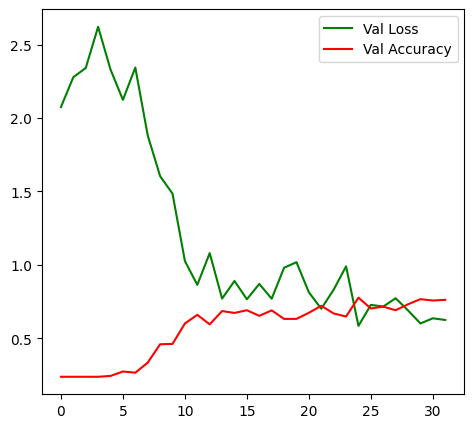

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'],label='Val Loss', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',color='red')
plt.legend()
plt.show()

### Observation
It performs very well than the CNN without the data augmentation layer . The accuracy gained was around 10% also the curve is more stable that that. Its just like we get more data to train on(more epoch means more data or would have settled before)

But see how noisy and confused our small CNN(compared to fineTuned) is. Even after 50 Epochs it struggles to learn. Not very small compared to classic VGG but still very small. And it is expected because of such small data it struggeles as it is being trained from the scratch.